# Heart Disease Prediction Project
## Optimized & Refactored Workflow

**Changes made:**
- consolidated imports
- Fixed data leakage (Train/Test Split applied properly before training)
- Implemented Cross-Validation for robust model comparison
- Automated Hyperparameter Tuning for the best model
- Unified Feature Selection and Preprocessing

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Metrics & Saving
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, 
    roc_auc_score, RocCurveDisplay
)
import joblib

# Configuration
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
%matplotlib inline

In [ ]:
# 2. Load Data
try:
    df = pd.read_csv("../data/heart.csv")
    print("Dataset Loaded Successfully from ../data/heart.csv")
    print("Shape:", df.shape)
except FileNotFoundError:
    print("Error: Dataset not found. Please ensure 'heart.csv' is in the '../data/' directory.")

# Basic Inspection
if 'df' in locals():
    display(df.head())
    display(df.info())

In [ ]:
# 3. Exploratory Data Analysis (EDA)
if 'df' in locals():
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Target Distribution
    sns.countplot(x='target', data=df, ax=ax[0], palette='coolwarm')
    ax[0].set_title("Distribution of Target Variable")

    # Correlation Heatmap
    # Drop non-numeric for correlation if needed, but this dataset is mostly numeric
    sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5, ax=ax[1])
    ax[1].set_title("Feature Correlation Matrix")

    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Preprocessing & Data Splitting
if 'df' in locals():
    # Separate Features and Target
    X = df.drop("target", axis=1)
    y = df["target"]

    # Identify Numerical and Categorical columns automatically
    categorical_cols = [col for col in X.columns if X[col].nunique() < 10]  # Simplistic heuristic
    numerical_cols = [col for col in X.columns if col not in categorical_cols]

    print("Categorical Features:", categorical_cols)
    print("Numerical Features:", numerical_cols)

    # Define Preprocessing Pipelines
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")

In [ ]:
# 5. Model Comparison (Cross-Validation)
if 'X_train' in locals():
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "SVM": SVC(probability=True, random_state=42),
        "KNN": KNeighborsClassifier(),
        "MLP Neural Net": MLPClassifier(max_iter=1000, random_state=42)
    }

    results = {}
    print("Cross-Validation Scores (Accuracy):\n")

    for name, model in models.items():
        clf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('selector', SelectKBest(score_func=f_classif, k='all')), 
                              ('classifier', model)])
        
        cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
        results[name] = cv_scores.mean()
        print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    best_model_name = max(results, key=results.get)
    print(f"\nBest Baseline Model: {best_model_name} ({results[best_model_name]:.4f})")

In [ ]:
# 6. Hyperparameter Tuning
if 'best_model_name' in locals():
    print(f"Tuning {best_model_name}...")

    param_grids = {
        "Decision Tree": {
            'classifier__criterion': ['gini', 'entropy', 'log_loss'],
            'classifier__max_depth': [None, 3, 5, 7, 10, 15],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4, 6]
        },
        "Random Forest": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5]
        },
        "Gradient Boosting": {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 5]
        },
        "Logistic Regression": {
            'classifier__C': [0.1, 1, 10],
            'classifier__solver': ['liblinear', 'lbfgs']
        },
        "KNN": {
            'classifier__n_neighbors': [3, 5, 7, 9],
            'classifier__weights': ['uniform', 'distance']
        },
        "SVM": {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        }
    }

    grid = param_grids.get(best_model_name, {})

    final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('selector', SelectKBest(score_func=f_classif, k='all')),
                                     ('classifier', models[best_model_name])])

    if grid:
        search = GridSearchCV(final_pipeline, grid, cv=5, scoring='accuracy', n_jobs=-1)
        search.fit(X_train, y_train)
        best_estimator = search.best_estimator_
        print("Best Params:", search.best_params_)
        print("Best CV Score:", search.best_score_)
    else:
        print(f"No specific grid for {best_model_name}, using default parameters.")
        best_estimator = final_pipeline
        best_estimator.fit(X_train, y_train)

In [ ]:
# 7. Final Evaluation
if 'best_estimator' in locals():
    y_pred = best_estimator.predict(X_test)
    y_proba = best_estimator.predict_proba(X_test)[:, 1]

    print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f"Confusion Matrix ({best_model_name})")
    ax[0].set_ylabel("True Label")
    ax[0].set_xlabel("Predicted Label")

    # ROC Curve
    RocCurveDisplay.from_estimator(best_estimator, X_test, y_test, ax=ax[1])
    ax[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
    ax[1].plot([0, 1], [0, 1], 'k--')

    plt.tight_layout()
    plt.show()

In [ ]:
# 8. Save The Model
if 'best_estimator' in locals():
    joblib.dump(best_estimator, "../heart_disease_model.pkl")
    print("Final model saved as '../heart_disease_model.pkl'")

## Decision Tree Specific Analysis
In addition to the baseline comparison, we explicitly analyze a Decision Tree model here as requested.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

if 'X_train' in locals() and 'preprocessor' in locals():
    print("\nRunning specific Decision Tree Analysis...")
    # 8. Build Pipeline with Decision Tree
    dtree = DecisionTreeClassifier(random_state=42)
    pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', dtree)])

    # 9. Hyperparameter Tuning
    param_grid_dt = {
        'classifier__criterion': ['gini', 'entropy', 'log_loss'],
        'classifier__max_depth': [None, 3, 5, 7, 10, 15],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4, 6]
    }

    grid_search_dt = GridSearchCV(
        pipeline_dt,
        param_grid_dt,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search_dt.fit(X_train, y_train)

    print("Best Params (Decision Tree):", grid_search_dt.best_params_)
    print("Best CV Score (Decision Tree):", grid_search_dt.best_score_)

    # 10. Evaluate on Test Set
    y_pred_dt = grid_search_dt.predict(X_test)
    print("\nTest Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dt))
    print("\nClassification Report (Decision Tree):\n", classification_report(y_test, y_pred_dt))

    # Confusion Matrix
    cm_dt = confusion_matrix(y_test, y_pred_dt)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix (Decision Tree)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC-AUC
    y_proba_dt = grid_search_dt.predict_proba(X_test)[:,1]
    roc_score_dt = roc_auc_score(y_test, y_proba_dt)
    print("ROC-AUC Score (Decision Tree):", roc_score_dt)
    RocCurveDisplay.from_estimator(grid_search_dt, X_test, y_test)
    plt.show()

    # 11. Save Final Model
    joblib.dump(grid_search_dt.best_estimator_, "../decisiontree_heart_model.pkl")
    print("Decision Tree model saved as '../decisiontree_heart_model.pkl'")

## Alternative Workflow: Random Forest with Top 10 Features
This section implements an alternative Random Forest analysis using explicit `SelectKBest` feature selection prior to preprocessing.

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Target Distribution:
target
1    165
0    138
Name: count, dtype: int64


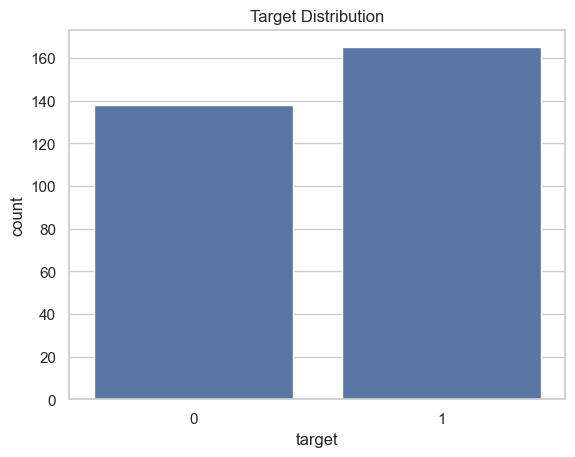

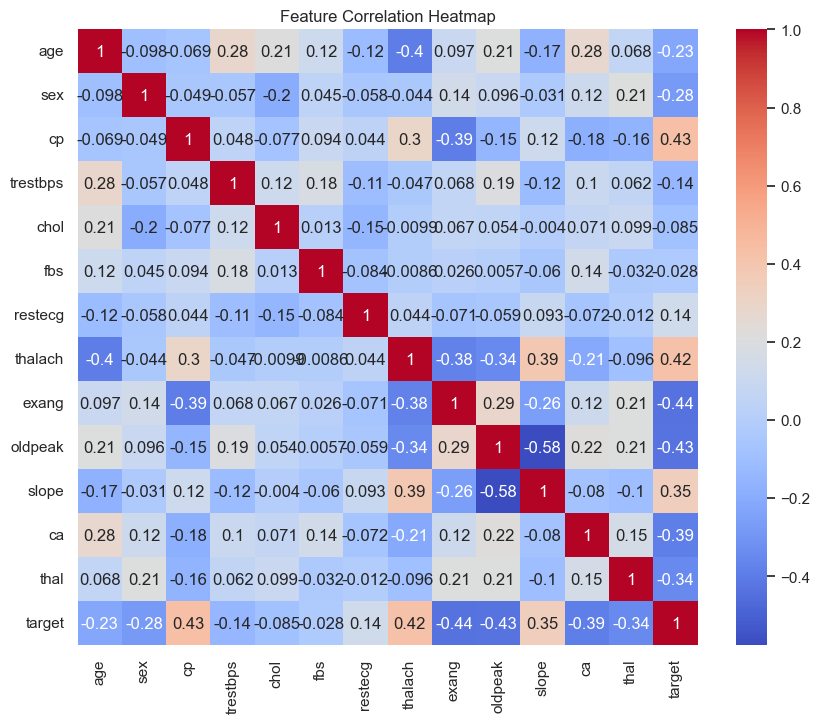

Selected Features: ['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [21]:
# ================================
# 2. Load Data (Reloading for this section)
# ================================
try:
    # Using project path
    df = pd.read_csv("../data/heart.csv")
    print("Shape:", df.shape)
    display(df.head())
except FileNotFoundError:
    print("Dataset not found in ../data/heart.csv, please check path.")


# ================================
# 3. Basic EDA
# ================================
print("\nTarget Distribution:")
if 'df' in locals():
    print(df['target'].value_counts())
    sns.countplot(x='target', data=df)
    plt.title("Target Distribution")
    plt.show()

    # Correlation Heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title("Feature Correlation Heatmap")
    plt.show()

    # ================================
    # 4. Define Features & Target
    # ================================
    X = df.drop('target', axis=1)
    y = df['target']

    # ================================
    # 5. Feature Selection
    # ================================
    # Note: Applying feature selection before splitting can introduce data leakage.
    # Proceeding as per provided workflow.
    selector = SelectKBest(score_func=f_classif, k=10)
    X_new = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support(indices=True)].tolist()
    print("Selected Features:", selected_features)

    X = df[selected_features]

    categorical_features = [col for col in ['sex','cp','fbs','restecg','exang','slope','ca','thal'] if col in selected_features]
    numerical_features = [col for col in selected_features if col not in categorical_features]

    # ================================
    # 6. Preprocessing
    # ================================
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor_rf = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # ================================
    # 7. Train/Test Split
    # ================================
    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2,
                                                        random_state=42, stratify=y)

In [ ]:
# ================================
# 8. Train & Tune Random Forest
# ================================
if 'X_train_rf' in locals():
    print("\nTraining Random Forest on selected features...")
    
    rf = RandomForestClassifier(random_state=42)
    pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor_rf),
                                  ('classifier', rf)])
    
    # Grid Search for Best Prediction
    param_grid_rf = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    }
    
    grid_search_rf = GridSearchCV(
        pipeline_rf,
        param_grid_rf,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search_rf.fit(X_train_rf, y_train_rf)
    
    print("Best Params (Random Forest):", grid_search_rf.best_params_)
    print("Best CV Score (Random Forest):", grid_search_rf.best_score_)
    
    # ================================
    # 9. Evaluate
    # ================================
    best_rf = grid_search_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test_rf)
    y_proba_rf = best_rf.predict_proba(X_test_rf)[:, 1]

    print("\nTest Accuracy (Random Forest):", accuracy_score(y_test_rf, y_pred_rf))
    print("\nClassification Report (Random Forest):\n", classification_report(y_test_rf, y_pred_rf))

    plt.figure(figsize=(6, 5))
    cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
    plt.title("Confusion Matrix (Random Forest)")
    plt.show()
    
    # ROC-AUC
    print("ROC-AUC Score (Random Forest):", roc_auc_score(y_test_rf, y_proba_rf))
    RocCurveDisplay.from_estimator(best_rf, X_test_rf, y_test_rf)
    plt.show()
    
    # Save Model
    joblib.dump(best_rf, "../random_forest_kbest_model.pkl")
    print("Random Forest model saved as '../random_forest_kbest_model.pkl'")